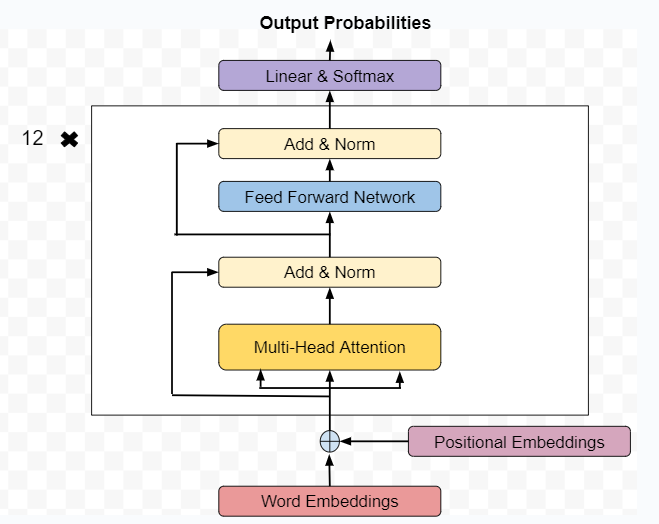

In [3]:
import torch as t
from torch import nn
import torch.nn.functional as F 
import math 
import numpy 

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self , d_model , n_heads):
        super().__init__()
        self.d_model = d_model 
        self.n_heads = n_heads
        self.d_k =d_model // n_heads

        
        self.Wq = nn.Linear(d_model , self.d_k*n_heads)
        self.Wk = nn.Linear(d_model , self.d_k*n_heads)
        self.Wv = nn.Linear(d_model , self.d_k*n_heads)
        self.fc = nn.Linear(self.d_k * n_heads, d_model)
    
    def forward(self, x):
        N , T , _ = x.shape
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        
        Q = Q.view(N, T, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(N, T, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(N, T, self.n_heads, self.d_k).transpose(1, 2)
        #score
        # Note : dont use K.T becuase it is 3 dim not 2d (B , T , d_model)
        score = (Q@K.transpose(-2,-1))/(t.sqrt( t.tensor(self.d_k , dtype=t.float32)))
        weight = F.softmax(score , dim=-1) # softmax needs float
        
        A = weight@V
        A = A.transpose(1,2).contiguous().view(N , T , self.d_k*self.n_heads)
        
        return self.fc(A)

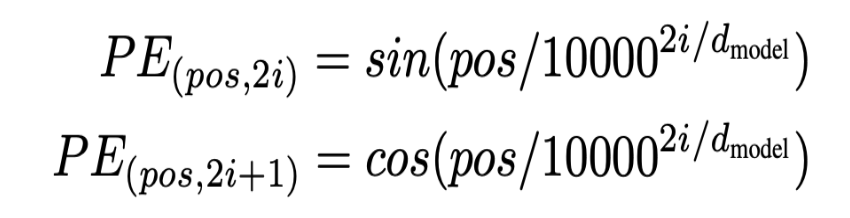

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self , T , d_model):
        super().__init__()
        self.T = T
        self.d_model = t.tensor(d_model)
        PE = t.zeros((self.T , self.d_model))
        for pos in range(self.T):
            for i in range( 0 , self.d_model , 2):
                PE[pos , i] = t.sin(pos/(10000 ** (2*i/self.d_model)))
                PE[pos , i+1] = t.cos(pos/(10000 ** (2*i/self.d_model)))
        
        self.register_buffer('PE' , PE) # = self.PE
        
    
    def forward(self, x):
        N , T , _ = x.shape 
        return x + self.PE[:T].unsqueeze(0)

In [6]:

class AddNorm(nn.Module):
    def __init__(self, d_model , n_heads):
        super().__init__()
        self.ln = nn.LayerNorm(d_model)
        self.d_model = d_model
        self.n_heads = n_heads
        self.MHA = MultiHeadAttention(d_model , n_heads)
    def forward(self,x , operation_output):
        output = x + operation_output
        output = self.ln(output)
        return output

In [ ]:
class FFN(nn.Module):
    def __init__(self , d_model):
        super().__init__()
        self.d_model = d_model
        d_ff = 4*d_model
        
        self.network = nn.Sequential(
            nn.Linear(d_model , d_ff),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_ff , d_model),
        )
    def forward(self ,x):
        return self.network(x)

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self , d_model , n_heads):
        super().__init__()
        self.mha = MultiHeadAttention(d_model , n_heads)
        self.addNorm1 = AddNorm(d_model , n_heads)
        self.ffn = FFN(d_model)
        self.addNorm2 = AddNorm(d_model , n_heads)
    def forward(self , x) :
        x = self.addNorm1(x , self.mha(x))
        x = self.addNorm2(x , self.ffn(x))
        
        return x


In [9]:
class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, N_layers):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads) for _ in range(N_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [10]:

from datasets import load_dataset

ds = load_dataset("stanfordnlp/sst2")

In [11]:
from transformers import AutoTokenizer
checkpoint = "bert-base-uncased"
Tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [234]:
ds["train"]

Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 67349
})

In [235]:
from torch.utils.data import DataLoader , TensorDataset
def tokenize(batch):
    return Tokenizer(batch["sentence"], truncation=True, 
                     padding="max_length", max_length=128, return_tensors="pt")

encoded = tokenize(ds["train"][:])
X = encoded["input_ids"]   # token ids → feed this to model
Y = t.tensor(ds["train"]["label"])

data = TensorDataset(X , Y)
train_data = DataLoader(data , batch_size=32)

In [12]:
class Model(nn.Module):
    def __init__(self , vocab_size , T , d_model , n_heads , N_layers , out_features):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size , d_model)
        self.positonalEncoding = PositionalEncoding(T , d_model)
        self.encoder = Encoder(d_model , n_heads , N_layers)
        self.classifier = nn.Linear(d_model , out_features)
        
    def forward(self, x):
        x = self.embeddings(x)
        x = self.positonalEncoding(x)
        x = self.encoder(x)
        x = x[:,0,:]
        return self.classifier(x)

In [13]:
from dataclasses import dataclass

@dataclass
class EncoderConfig:
    vocab_size: int = 30522
    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 4
    d_ff: int = 512
    max_len: int = 128
    dropout: float = 0.1
    num_classes: int = 2
    lr: float = 2e-4
    batch_size: int = 32
    epochs: int = 5
    device: str = "cuda" if t.cuda.is_available() else "cpu"

cfg = EncoderConfig()

# then use it like:
model = Model(
    vocab_size=cfg.vocab_size,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    N_layers=cfg.n_layers,
    T=cfg.max_len,
    out_features=cfg.num_classes
).to(cfg.device)

In [238]:
optimizer = t.optim.AdamW(model.parameters(), lr=2e-4)
loss_fn = t.nn.CrossEntropyLoss()

for epoch in range(cfg.epochs):
    model.train()
    for X_batch, Y_batch in train_data:
        X_batch = X_batch.to(cfg.device)  # shape: (batch, seq_len) — token ids
        Y_batch = Y_batch.to(cfg.device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = loss_fn(logits, Y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

Epoch 1 | Loss: 0.3307
Epoch 2 | Loss: 0.3526
Epoch 3 | Loss: 0.1819
Epoch 4 | Loss: 0.1465
Epoch 5 | Loss: 0.1238


In [239]:
encoded = tokenize(ds["validation"][:])
X_test= encoded["input_ids"]   # token ids → feed this to model
Y_test = t.tensor(ds["validation"]["label"])

data = TensorDataset(X_test , Y_test)
test_data = DataLoader(data , batch_size=32)

In [240]:
from sklearn.metrics import accuracy_score, classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, Y_batch in test_data:
        X_batch = X_batch.to(cfg.device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(Y_batch.tolist())

acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc:.4f}")
print(classification_report(all_labels, all_preds, labels=[0, 1], target_names=["Negative", "Positive"]))

Accuracy: 0.7718
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.77       428
    Positive       0.77      0.78      0.78       444

    accuracy                           0.77       872
   macro avg       0.77      0.77      0.77       872
weighted avg       0.77      0.77      0.77       872



In [248]:
model.eval()

sentence = "This movie was not amazing!"

inputs = Tokenizer(sentence, return_tensors="pt", 
                   truncation=True, padding="max_length", max_length=128)

X = inputs["input_ids"].to(cfg.device)

with t.no_grad():
    logits = model(X)
    pred = t.argmax(logits, dim=-1).item()

label = "Positive 😊" if pred == 1 else "Negative 😔"
print(f"Sentence: {sentence}")
print(f"Prediction: {label}")

Sentence: This movie was not amazing!
Prediction: Negative 😔
